In [1]:
from copy import copy

import pandas as pd
import seaborn as sns
import wandb
from matplotlib.ticker import FuncFormatter
from wandb.apis.public.runs import Run

In [2]:
api = wandb.Api()

In [3]:
runs = api.runs("graphcore/llama-mobile", filters={"config.name": "sweep-formats-v1"})

In [4]:
def cleanup_run(run: Run) -> dict[str, any]:
    fmt = run.config["quantisation_formats"][1][1]

    d = {}
    # NOTE: format is None if not-quantised
    d["format"] = None
    d["scaling"] = None
    if fmt["_type"] == "linear":
        el_format = fmt["element_format"]
        type = el_format["_type"]
        if type == "fp":
            d["format"] = f"E{el_format['exponent_bits']}M{el_format['mantissa_bits']}"
        elif type == "int":
            d["format"] = f"INT{el_format['bits_']}"
        else:
            raise ValueError("Unexpected element format _type")
        row, col = fmt["group_shapes"][0]
        if row is None and col is None:
            d["scaling"] = "Tensor"
        elif row == 1 and col is None:
            d["scaling"] = "channel-out"
        elif row is None and col == 1:
            d["scaling"] = "clannel-in"
        else:
            d["scaling"] = f"group ({row}, {col})"
        
            
    d.update(run.summary)
    d.pop("_wandb")
    return d

In [5]:
df = pd.DataFrame([cleanup_run(run) for run in runs])

In [6]:
df

,format,scaling,duration,edit_distance_L16,edit_distance_L16_stderr,entropy_rmse,entropy_rmse_stderr,exact_match_length,exact_match_length_stderr,n_bytes,n_params
0,None,None,519.211715,0.000,0.000000,0.000000,0.000000,64.000000,0.000000,21340441670,10670220835
1,E5M2,Tensor,483.733763,5.104,0.239661,0.581489,0.014698,16.544001,0.861834,10747695196,10670220835
2,E5M2,clannel-in,482.928391,5.466,0.239341,0.576619,0.015109,13.628000,0.735018,10751760454,10670220835
3,E5M2,channel-out,484.390700,5.352,0.240124,0.553615,0.013267,14.602000,0.770654,10752577622,10670220835
4,E5M2,"group (1, 8)",485.241496,4.250,0.236878,0.449807,0.011743,20.086000,0.926651,13395881030,10670220835
...,...,...,...,...,...,...,...,...,...,...,...
59,INT3,channel-out,498.483775,15.934,0.011470,10.090466,0.055535,0.018000,0.005952,4132110422,10670220835
60,INT3,"group (1, 8)",480.008878,10.668,0.181917,1.198934,0.019232,2.512000,0.159746,6775413830,10670220835
61,INT3,"group (1, 16)",502.014447,12.092,0.164479,1.492701,0.022156,1.688000,0.165469,5451320390,10670220835
62,INT3,"group (1, 32)",499.038456,12.940,0.129562,1.729022,0.024625,1.184000,0.082279,4789273670,10670220835


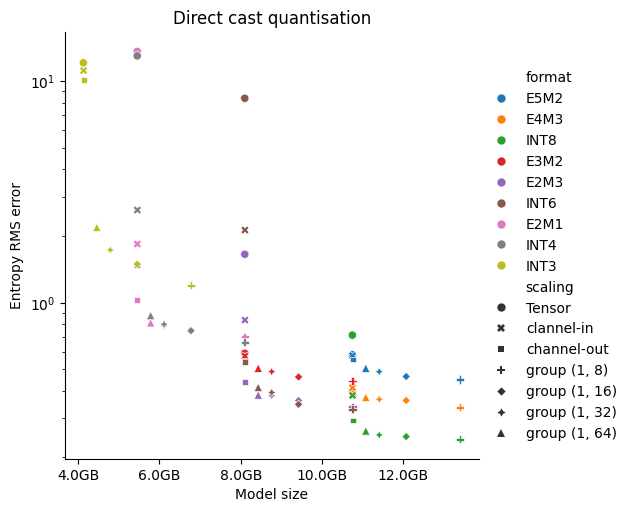

In [7]:
p = sns.relplot(df, x="n_bytes", y="entropy_rmse", hue="format", style="scaling")
ax = p.ax
ax.set_xlabel("Model size")
ax.set_ylabel("Entropy RMS error")
ax.set_yscale("log")
ax.set_title("Direct cast quantisation")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x / 1e9}GB"))